## Device change prediction, training and prediction

### Subtask:
Last inn data fra BigQuery-tabellen `tnn-consumer-common-nx.DataScience.device_change_abt_sampled` til en pandas DataFrame ved hjelp av `bigframes.pandas`.


In [ ]:
import bigframes.pandas as bpd

bpd.close_session()
bpd.options.bigquery.project = "tnn-consumer-common-nx"

df = bpd.read_gbq("tnn-consumer-common-nx.DataScience.device_change_abt", use_cache=False).to_pandas()
df.head()
#print(f"Shape of df_new: {df.shape}")

,main_number_sk,period_month_date,device_producername,device_release_date,device_category,device_group,current_device,device_producername_APPLE,device_producername_SAMSUNG,device_producername_DORO,...,med_change_days,avg_gen_days_first_use_after_release,avg_gen_change_days,med_gen_change_days,stddev_gen_change_days,avg_dev_days_first_use_after_release,avg_dev_change_days,med_dev_change_days,stddev_dev_change_days,current_purchase_month_nr
0,3204057170.000000000,2023-07-31,APPLE,2021-09-30,SMARTPHONE 5G,Mobile phone,IPHONE 13 PRO,1,0,0,...,411.5,251.305829,1184.712714,1032.153846,784.073128,334.521739,670.812451,670.812451,307.894268,6
1,3181949495.000000000,2022-10-31,APPLE,2019-09-30,SMARTPHONE 4G,Mobile phone,IPHONE 11 PRO MAX,1,0,0,...,975.0,240.427739,1203.947401,1058.384615,769.679843,350.541667,736.004833,736.004833,470.90504,10
2,3175199136.000000000,2023-07-31,APPLE,2018-09-30,SMARTPHONE 4G,Mobile phone,IPHONE XS,1,0,0,...,883.5,251.305829,1184.712714,1032.153846,784.073128,350.041667,890.630678,890.630678,510.122093,8
3,3183015525.000000000,2022-11-30,SAMSUNG,2019-03-31,SMARTPHONE 4G,Mobile phone,GALAXY S10E,0,1,0,...,1187.5,242.741453,1206.166999,1058.384615,773.519293,350.791667,938.652908,938.652908,589.466327,12
4,3186537686.000000000,2025-04-30,APPLE,2024-09-30,SMARTPHONE 5G,Mobile phone,IPHONE 16 PRO,1,0,0,...,822.0,237.707857,1282.493867,1119.307692,839.700158,106.5,255.758143,255.758143,51.019688,4


In [ ]:
y = df['device_target']
X = df.drop('device_target', axis=1)

print("Target variable 'y' and feature DataFrame 'X' have been created.")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

In [ ]:
from sklearn.model_selection import train_test_split

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("Data successfully split into training and test sets with stratification.")

Shape of X_train: (405191, 82)
Shape of X_test: (101298, 82)
Shape of y_train: (405191,)
Shape of y_test: (101298,)
Data successfully split into training and test sets with stratification.


## Train XGBoost Model

### Subtask:
Initialize and train an `XGBClassifier` model on the updated `X_train` and `y_train` data. We will use `random_state=42` for reproducibility and set `eval_metric='logloss'`.

In [ ]:
import xgboost as xgb

# Identify and handle problematic columns in X_train and X_test
problematic_numerical_cols = ['main_number_sk']
date_cols = ['period_month_date', 'device_release_date']
categorical_string_cols = [
    'device_producername', 'device_category', 'device_group',
    'current_device', 'device_name', 'manufacturer',
    'device_series_annual', 'display_type', 'context_summary', 'generation'
]

# Convert 'main_number_sk' to float
X_train['main_number_sk'] = X_train['main_number_sk'].astype(float)
X_test['main_number_sk'] = X_test['main_number_sk'].astype(float)

# Drop raw date columns as their derived numerical features (e.g., current_device_days) already exist
# Check if columns exist before dropping to handle re-runs of the cell
X_train = X_train.drop(columns=[col for col in date_cols if col in X_train.columns])
X_test = X_test.drop(columns=[col for col in date_cols if col in X_test.columns])

# Convert identified string columns to categorical type
for col in categorical_string_cols:
    # Explicitly convert to string (object dtype) first, then to category to handle pyarrow types
    X_train[col] = X_train[col].astype(str).astype('category')
    X_test[col] = X_test[col].astype(str).astype('category')


# Initialize and train the XGBoost classifier model
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss', enable_categorical=True)

# Fit the model to the training data
xgb_model.fit(X_train, y_train)

print("XGBoost model training complete.")

XGBoost model training complete.


In [ ]:
import joblib

# Define the path to save the model
model_path = "/content/device_change_xgb.joblib"

# Save the trained XGBoost model
joblib.dump(xgb_model, model_path)

print(f"XGBoost model saved successfully to {model_path}")

XGBoost model saved successfully to /content/device_change_xgb.joblib


## Evaluate XGBoost Model

### Subtask:
Predict class labels and probabilities on the test set using the newly trained XGBoost model. Calculate and print the ROC AUC score, display the confusion matrix, and output accuracy, precision, recall, and F1-score.

XGBoost predictions on test set are made.
XGBoost Nøyaktighet (Accuracy): 0.8579
XGBoost Presisjon (Precision): 0.7961
XGBoost Gjenkalling (Recall): 0.9425
XGBoost F1-score: 0.8631
XGBoost ROC AUC Score: 0.9218


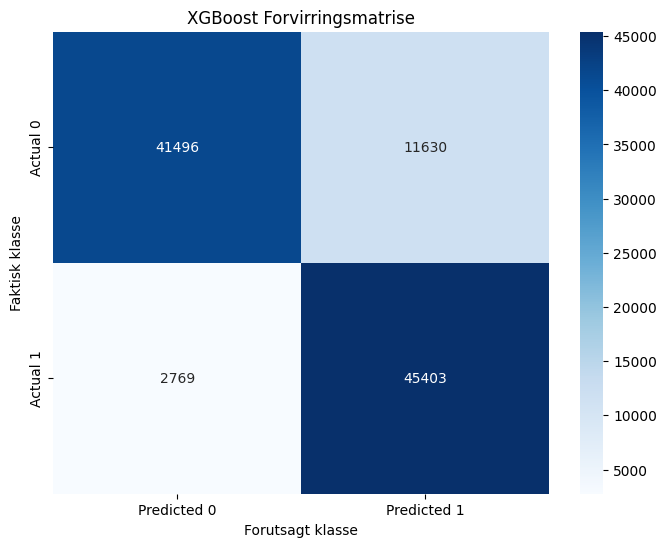

XGBoost forvirringsmatrise er beregnet og visualisert.
Top 10 mest innflytelsesrike funksjoner i XGBoost-modellen:

current_device_days                0.426473
current_days_vs_avg_change_days    0.090684
med_change_days                    0.075380
device_name                        0.043519
avg_change_days                    0.039120
mb_last1                           0.034488
current_purchase_month_nr          0.028761
stddev_gen_change_days             0.022392
days_first_use_after_release       0.021239
context_summary                    0.019917
dtype: float32


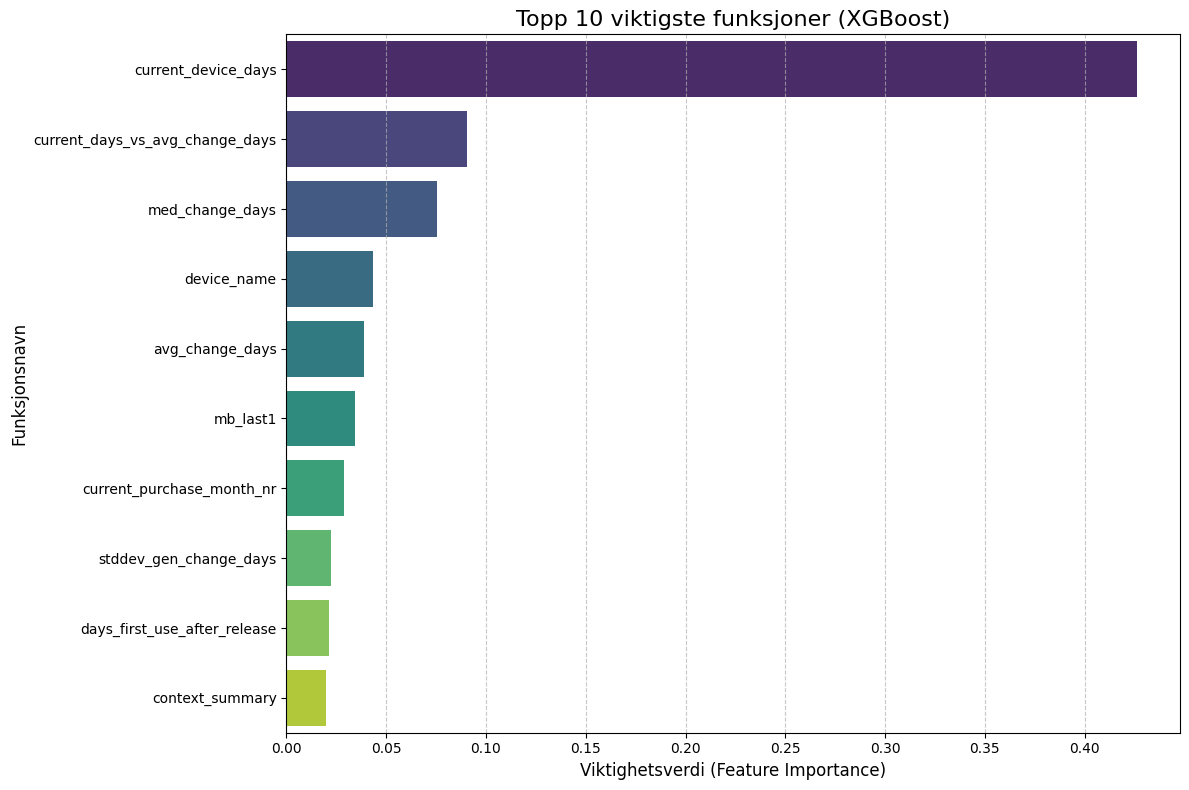

Topp 10 viktigste funksjoner visualisert.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Predict class labels on the test set using the XGBoost model
y_pred_xgb = xgb_model.predict(X_test)

# Predict probabilities for the positive class on the test set using the XGBoost model
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost predictions on test set are made.")

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print(f"XGBoost Nøyaktighet (Accuracy): {accuracy_xgb:.4f}")
print(f"XGBoost Presisjon (Precision): {precision_xgb:.4f}")
print(f"XGBoost Gjenkalling (Recall): {recall_xgb:.4f}")
print(f"XGBoost F1-score: {f1_xgb:.4f}")

roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)
print(f"XGBoost ROC AUC Score: {roc_auc_xgb:.4f}")

# Calculate the confusion matrix for the XGBoost model
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('XGBoost Forvirringsmatrise')
plt.xlabel('Forutsagt klasse')
plt.ylabel('Faktisk klasse')
plt.show()

print("XGBoost forvirringsmatrise er beregnet og visualisert.")

# Get feature importances from the trained xgb_model
feature_importances = xgb_model.feature_importances_

# Create a Pandas Series with feature names from X_train.columns and their importances
feature_importance_series = pd.Series(feature_importances, index=X_train.columns)

# Sort the Series in descending order
sorted_feature_importances = feature_importance_series.sort_values(ascending=False)

# Print the top 10 most important features
print("Top 10 mest innflytelsesrike funksjoner i XGBoost-modellen:\n")
print(sorted_feature_importances.head(10))

# Select the top 10 features
top_10_features = sorted_feature_importances.head(10)

# Create a bar plot for the top 10 features
plt.figure(figsize=(12, 8))
sns.barplot(x=top_10_features.values, y=top_10_features.index, palette='viridis', hue=top_10_features.index, legend=False)
plt.title('Topp 10 viktigste funksjoner (XGBoost)', fontsize=16)
plt.xlabel('Viktighetsverdi (Feature Importance)', fontsize=12)
plt.ylabel('Funksjonsnavn', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Topp 10 viktigste funksjoner visualisert.")

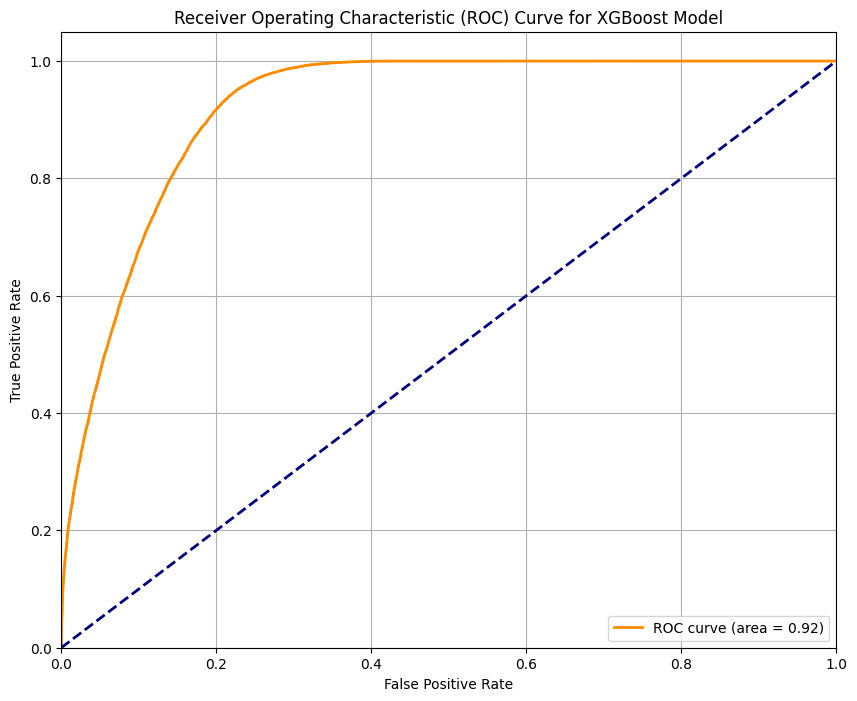


ROC AUC Score: 0.9218

--- Analyse av ROC-kurven ---
Modellen har en ROC AUC på 0.9218, noe som indikerer en utmerket evne til å skille mellom de positive og negative klassene.
Kurven ligger godt over den diagonale linjen, noe som bekrefter modellens sterke prediktive kraft.
ROC-kurven viser avveiningen mellom True Positive Rate (sensitivitet) og False Positive Rate (1-spesifisitet) for ulike terskelverdier.
Et høyt areal under kurven (AUC) betyr at modellen er god til å skille mellom klassene.


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Ensure y_proba is defined if running this cell independently, or use y_proba_xgb
y_proba = y_proba_xgb # Assuming y_proba_xgb is the intended probability array

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for XGBoost Model')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"\nROC AUC Score: {roc_auc:.4f}")

# Summarize the findings from the ROC curve
print("\n--- Analyse av ROC-kurven ---")
if roc_auc > 0.85:
    print(f"Modellen har en ROC AUC på {roc_auc:.4f}, noe som indikerer en utmerket evne til å skille mellom de positive og negative klassene.")
    print("Kurven ligger godt over den diagonale linjen, noe som bekrefter modellens sterke prediktive kraft.")
elif roc_auc > 0.7:
    print(f"Modellen har en ROC AUC på {roc_auc:.4f}, noe som indikerer en god evne til å skille mellom de positive og negative klassene.")
    print("Kurven viser at modellen har en betydelig bedre ytelse enn en tilfeldig gjetning.")
else:
    print(f"Modellen har en ROC AUC på {roc_auc:.4f}, noe som indikerer en moderat evne til å skille mellom de positive og negative klassene.")
    print("Det kan være rom for forbedring av modellen.")

print("ROC-kurven viser avveiningen mellom True Positive Rate (sensitivitet) og False Positive Rate (1-spesifisitet) for ulike terskelverdier.")
print("Et høyt areal under kurven (AUC) betyr at modellen er god til å skille mellom klassene.")

## Prediction on current data

### Subtask:
Load the preprocessed customer data directly from the BigQuery table `tnn-consumer-common-nx.DataScience.device_prediction`.


In [ ]:
import pandas as pd
import bigframes.pandas as bpd
import joblib
import xgboost as xgb
from sklearn.model_selection import train_test_split

# --- 1. Load the trained XGBoost model ---
model_path = "/content/device_change_xgb.joblib"
xgb_model = joblib.load(model_path)
print(f"XGBoost model loaded successfully from {model_path}")

# --- 2. Load the new data for prediction ---
bpd.options.bigquery.project = "tnn-consumer-common-nx"
sdf = bpd.read_gbq("tnn-consumer-common-nx.DataScience.device_change_prediction", use_cache=False).to_pandas()
print(f"Preprocessed prediction data loaded successfully. Shape: {sdf.shape}")

# --- 3. Recreate the training data's structure for consistent preprocessing ---
# This is crucial to ensure the prediction data matches the training data format
print("Recreating training data structure for alignment...")
temp_df_for_schema = bpd.read_gbq("tnn-consumer-common-nx.DataScience.device_change_abt", use_cache=False).to_pandas()
temp_X = temp_df_for_schema.drop('device_target', axis=1)

# Apply the same preprocessing steps as in the original training (cell 94d51953)
# Define preprocessing parameters (from cell 94d51953 and 16b58d90)
date_cols_to_drop_from_training = ['period_month_date', 'device_release_date']
categorical_string_cols_for_training = [
    'device_producername', 'device_category', 'device_group',
    'current_device', 'device_name', 'manufacturer',
    'device_series_annual', 'display_type', 'context_summary', 'generation'
]

# Convert 'main_number_sk' to float
temp_X['main_number_sk'] = temp_X['main_number_sk'].astype(float)

# Drop raw date columns from the schema reference DataFrame
temp_X = temp_X.drop(columns=[col for col in date_cols_to_drop_from_training if col in temp_X.columns])

# Convert identified string columns to categorical type in the schema reference DataFrame
for col in categorical_string_cols_for_training:
    if col in temp_X.columns:
        temp_X[col] = temp_X[col].astype(str).astype('category')

# Identify 'current_device_first_use_date' if it was part of the original training features
# and was not explicitly dropped. If it exists, drop it to match previous effective X_train.
if 'current_device_first_use_date' in temp_X.columns:
    temp_X = temp_X.drop(columns=['current_device_first_use_date'])

# Get the final list of features and their dtypes from the (recreated) training data
training_features = list(temp_X.columns)
training_dtypes = temp_X.dtypes

print("Training data structure recreated. Proceeding with prediction data preprocessing...")

# --- 4. Preprocess the prediction data (sdf) to match training data ---

# Make a copy to avoid modifying the original `sdf` directly before predictions are added
sdf_processed = sdf.copy()

# Convert 'main_number_sk' to float (consistent with training)
sdf_processed['main_number_sk'] = sdf_processed['main_number_sk'].astype(float)

# Drop raw date columns (consistent with training)
sdf_processed = sdf_processed.drop(
    columns=[col for col in date_cols_to_drop_from_training if col in sdf_processed.columns]
)

# Drop 'customer_sk_user' as it's not a feature for prediction
if 'customer_sk_user' in sdf_processed.columns:
    sdf_processed = sdf_processed.drop(columns=['customer_sk_user'])

# Explicitly drop 'current_device_first_use_date' if it exists in sdf_processed
# to ensure feature consistency with the training data (as determined by temp_X)
if 'current_device_first_use_date' in sdf_processed.columns:
    sdf_processed = sdf_processed.drop(columns=['current_device_first_use_date'])

# Align categorical columns: Convert to categorical type using categories from training data
for col in categorical_string_cols_for_training:
    if col in sdf_processed.columns and col in training_dtypes and pd.api.types.is_categorical_dtype(training_dtypes[col]):
        # Convert to string first to handle potential pyarrow types, then to category
        sdf_processed[col] = pd.Categorical(
            sdf_processed[col].astype(str),
            categories=training_dtypes[col].categories # Use categories from recreated training data
        )

# Align columns: Add missing columns with NaN and drop extra columns
missing_cols = set(training_features) - set(sdf_processed.columns)
for c in missing_cols:
    sdf_processed[c] = None # Or pd.NA, or a suitable default

extra_cols = set(sdf_processed.columns) - set(training_features)
sdf_processed = sdf_processed.drop(columns=list(extra_cols))

# Ensure column order matches training data
sdf_final_for_prediction = sdf_processed[training_features]

# Ensure dtypes are consistent (especially for float/int conversions after NaNs)
for col in training_features:
    if pd.api.types.is_float_dtype(training_dtypes[col]) and not pd.api.types.is_categorical_dtype(training_dtypes[col]):
        sdf_final_for_prediction[col] = pd.to_numeric(sdf_final_for_prediction[col], errors='coerce')
    elif pd.api.types.is_integer_dtype(training_dtypes[col]) and not pd.api.types.is_categorical_dtype(training_dtypes[col]):
        # For integer columns, convert to float first if there are NaNs, then back to Int64 if no NaNs
        # XGBoost handles floats for numerical features well.
        sdf_final_for_prediction[col] = pd.to_numeric(sdf_final_for_prediction[col], errors='coerce')


print("Prediction data preprocessed and aligned.")

# --- 5. Make predictions ---
new_data_predictions = xgb_model.predict(sdf_final_for_prediction)
new_data_probabilities = xgb_model.predict_proba(sdf_final_for_prediction)[:, 1]

# --- 6. Add predictions to the original `sdf` DataFrame ---
sdf['device_change_score'] = new_data_probabilities
sdf['device_change_prediction'] = new_data_predictions

print("Predictions for new data generated successfully.")

# --- 7. Display the first few rows with predictions ---
display(sdf.head())

XGBoost model loaded successfully from /content/device_change_xgb.joblib


Preprocessed prediction data loaded successfully. Shape: (1113017, 83)
Recreating training data structure for alignment...


Training data structure recreated. Proceeding with prediction data preprocessing...


/tmp/ipython-input-1134959747.py:78: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if col in sdf_processed.columns and col in training_dtypes and pd.api.types.is_categorical_dtype(training_dtypes[col]):
/tmp/ipython-input-1134959747.py:78: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if col in sdf_processed.columns and col in training_dtypes and pd.api.types.is_categorical_dtype(training_dtypes[col]):
/tmp/ipython-input-1134959747.py:78: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if col in sdf_processed.columns and col in training_dtypes and pd.api.types.is_categorical_dtype(training_dtypes[col]):
/tmp/ipython-input-1134959747.py:78: DeprecationWarning: is_categorical_dtype is d

Prediction data preprocessed and aligned.
Predictions for new data generated successfully.


,main_number_sk,customer_sk_user,period_month_date,device_producername,device_release_date,device_category,device_group,current_device,device_producername_APPLE,device_producername_SAMSUNG,...,avg_gen_change_days,med_gen_change_days,stddev_gen_change_days,avg_dev_days_first_use_after_release,avg_dev_change_days,med_dev_change_days,stddev_dev_change_days,current_purchase_month_nr,device_change_score,device_change_prediction
0,3215805439.000000000,89560858,2025-12-31,APPLE,2024-09-30,SMARTPHONE 5G,Mobile phone,IPHONE 16 PRO MAX,1,0,...,1366.645175,1203.230769,906.996251,228.1875,203.451295,203.451295,43.081252,11,3.367597e-01,0
1,3206031075.000000000,44460668,2025-12-31,SAMSUNG,2024-03-31,SMARTPHONE 5G,Mobile phone,GALAXY A55 5G,0,1,...,1366.645175,1203.230769,906.996251,319.818182,275.330157,275.330157,82.797439,2,1.427759e-05,0
2,4068958114.000000000,147984634,2025-12-31,APPLE,2019-09-30,SMARTPHONE 4G,Mobile phone,IPHONE 11,1,0,...,1366.645175,1203.230769,906.996251,350.541667,893.362158,893.362158,525.262885,<NA>,4.625367e-10,0
3,4065714755.000000000,239792537,2025-12-31,APPLE,2017-09-30,SMARTPHONE 4G,Mobile phone,IPHONE 8,1,0,...,1366.645175,1203.230769,906.996251,364.96,1050.210017,1050.210017,601.665857,<NA>,4.569319e-10,0
4,3177385490.000000000,10753546,2025-12-31,APPLE,2021-09-30,SMARTPHONE 5G,Mobile phone,IPHONE 13 PRO MAX,1,0,...,1366.645175,1203.230769,906.996251,364.96,655.614083,655.614083,326.974631,10,7.090052e-01,1


In [ ]:
import bigframes.pandas as bpd
from datetime import datetime


bpd.options.bigquery.project = "tnn-consumer-common-nx" # Ensure project is set

# Get current month and year for the suffix
current_month_year = datetime.now().strftime("%Y%m")

# Define the target BigQuery table with the suffix
target_table = f"tnn-consumer-common-nx-gold.datascience.device_change_score_{current_month_year}"

# Save the DataFrame to BigQuery
# Using 'replace' to overwrite the table if it already exists
sdf.to_gbq(target_table, if_exists='replace')

print(f"DataFrame successfully saved to BigQuery table: {target_table}")

/tmp/ipython-input-741076132.py:15: FutureWarning: to_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.to_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.to_gbq
  sdf.to_gbq(target_table, if_exists='replace')
100%|██████████| 1/1 [00:00<00:00, 8160.12it/s]

DataFrame successfully saved to BigQuery table: tnn-consumer-common-nx-gold.datascience.device_change_score_202601
